In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from scipy import stats
import statsmodels.stats.api as sms
from matplotlib import rcParams
rcParams.update({'figure.autolayout': True})
pd.set_option('display.max_columns', 10)
pd.set_option('display.width', 350)



In [2]:
df = pd.read_csv("referral.csv")


   user_id        date country  money_spent  is_referral      device_id
0        2  2015-10-03      FR           65            0  EVDCJTZMVMJDG
1        3  2015-10-03      CA           54            0  WUBZFTVKXGQQX
2        6  2015-10-03      FR           35            0  CBAPCJRTFNUJG
3        7  2015-10-03      UK           73            0  PRGXJZAJKMXRH
4        7  2015-10-03      MX           35            0  PRGXJZAJKMXRH


In [5]:


print(df.describe())

            user_id   money_spent   is_referral
count  97341.000000  97341.000000  97341.000000
mean    6354.801029     44.692360      0.287823
std     5682.991186     22.791839      0.452751
min        1.000000     10.000000      0.000000
25%     2020.000000     27.000000      0.000000
50%     4053.000000     42.000000      0.000000
75%    10286.000000     59.000000      1.000000
max    20000.000000    220.000000      1.000000


In [8]:
df['date'] = pd.to_datetime(df['date'])

launch_date = '2015-10-31'

before = df[df['date'] < launch_date]
after = df[df['date'] >= launch_date]


In [13]:
b_nunique = before['user_id'].nunique()
a_nunique = after['user_id'].nunique()
b_len = len(before)
a_len = len(after)
b_rev = before['money_spent'].sum()
a_rev = after['money_spent'].sum()
print(b_nunique)
print(b_len)
print(b_rev)
print(a_nunique)
print(a_len)
print(a_rev)

5000
47341
2006396
18397
50000
2344003


In [14]:
daily_before = before.groupby("date").agg({
    'user_id':'nunique',
    'money_spent':'sum'
})

daily_after = after.groupby("date").agg({
    'user_id':'nunique',
    'money_spent':'sum'
})
print(daily_before.head(5))
print(daily_after.head(5))

            user_id  money_spent
date                            
2015-10-03     2283       128475
2015-10-04     2274       130772
2015-10-05     1030        46946
2015-10-06     1020        49711
2015-10-07      966        45242
            user_id  money_spent
date                            
2015-10-31     2963       151596
2015-11-01     2912       147049
2015-11-02     1171        56178
2015-11-03     1232        57173
2015-11-04     1146        57606


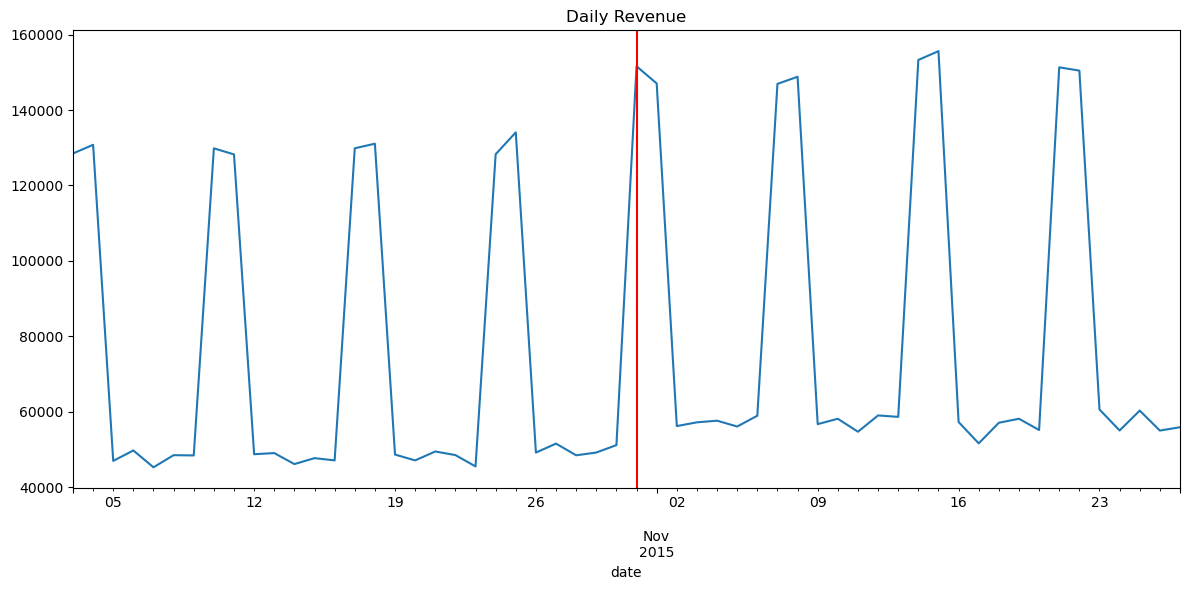

In [15]:
daily_revenue = df.groupby('date')['money_spent'].sum()
daily_revenue.plot(figsize = (12, 6))
plt.axvline(pd.to_datetime(launch_date), color='red')
plt.title("Daily Revenue")
plt.show()

In [16]:
t_stat, p_value = stats.ttest_ind(
    daily_before['money_spent'],
    daily_after['money_spent'],
    equal_var='False'
)

print(t_stat)
print(p_value)

-1.1138005775236357
0.270297918718587
